# **Data Analysis Heritage-Housing-Project**

## Objectives

This notebook focuses on exploring the relationship between house attributes and their sale prices. The analysis aims to support the client in understanding which features have the strongest influence on property value.

The outcome will help identify the key variables to include in the predictive model and inform the visualizations that will be part of the final dashboard.

## Inputs

- Dataset collected and stored in the previous notebook:
  `outputs/datasets/collection/house_prices_records.csv`

## Outputs

- Correlation matrix for numerical features
- Visualizations of selected variables with strong correlation to sale price
- Observations and summary of insights to support the next steps


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [15]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\PabloGalindo\\Coding-Institute\\PMS5'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [16]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [17]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\PabloGalindo\\Coding-Institute'

# Initial Data Exploration

## Load data for analysis

We will load here the data from  `outputs/datasets/collection/house_prices_records.csv`


In [18]:
import pandas as pd

# Define the path to the dataset
file_path = "outputs/datasets/collection/house_prices_records.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Preview the first few rows
df.head()




FileNotFoundError: [Errno 2] No such file or directory: 'outputs/datasets/collection/house_prices_records.csv'

---

## Exploring Feature Correlations with Sale Price

Before analyzing the lationships between features and the target variable, we will make an analysis of the dataset structure.

This includes:
- Reviewing the types of variables available
- Looking at their distribution
- Identifying missing values
- Considering how each feature might relate to the sale price in a business context

This step helps us better understand the structure of the data and prepares us for a more focused analysis of the most influential variables.



### Feature Glossary and Units of Measure

Before proceeding with the technical analysis of the data, it is important to establish a basic understanding of what each feature in the dataset represents, such as the units of measure, feature type, and possible value ranges. 

To support this, we summarize the information provided in the `house-metadata.txt` file. This simple analysis is helpful as it provides business context to the variables and improves explainability throughout the project.



#### Feature Glossary (Condensed with Categorical Meanings)

| Feature         | Unit / Type           | Range / Potential Values / Glossary                             |
|----------------|------------------------|------------------------------------------------------------------|
| 1stFlrSF        | sq ft                 | 334 – 4692                                                       |
| 2ndFlrSF        | sq ft                 | 0 – 2065                                                         |
| BedroomAbvGr    | count                 | 0 – 8                                                            |
| BsmtExposure    | category              | Gd: Good, Av: Average, Mn: Minimum, No: None, None: No Basement |
| BsmtFinType1    | category              | GLQ: Good Living Quarters, ALQ: Avg Living, BLQ: Below Avg, Rec: Rec Room, LwQ: Low Quality, Unf: Unfinished, None: No Basement |
| BsmtFinSF1      | sq ft                 | 0 – 5644                                                         |
| BsmtUnfSF       | sq ft                 | 0 – 2336                                                         |
| TotalBsmtSF     | sq ft                 | 0 – 6110                                                         |
| GarageArea      | sq ft                 | 0 – 1418                                                         |
| GarageFinish    | category              | Fin: Finished, RFn: Rough Finished, Unf: Unfinished, None: No Garage |
| GarageYrBlt     | year                  | 1900 – 2010                                                      |
| GrLivArea       | sq ft                 | 334 – 5642                                                       |
| KitchenQual     | category              | Ex: Excellent, Gd: Good, TA: Typical/Average, Fa: Fair, Po: Poor |
| LotArea         | sq ft                 | 1300 – 215245                                                    |
| LotFrontage     | linear ft             | 21 – 313                                                         |
| MasVnrArea      | sq ft                 | 0 – 1600                                                         |
| EnclosedPorch   | sq ft                 | 0 – 286                                                          |
| OpenPorchSF     | sq ft                 | 0 – 547                                                          |
| OverallCond     | ordinal (1–10)        | 1: Very Poor → 10: Very Excellent                                |
| OverallQual     | ordinal (1–10)        | 1: Very Poor → 10: Very Excellent                                |
| WoodDeckSF      | sq ft                 | 0 – 736                                                          |
| YearBuilt       | year                  | 1872 – 2010                                                      |
| YearRemodAdd    | year                  | 1950 – 2010                                                      |
| SalePrice       | USD                   | 34,900 – 755,000                                                 |



### Data Profiling

To support a better understanding of the underlying structure of the data, an automated profiling report will be generated using `ydata_profiling`. 

The output will be saved as an HTML file in the `outputs/reports/` folder. This report provides a comprehensive overview of the dataset, including:

- Variable types and summary statistics
- Distributions and potential outliers
- Missing values and data quality alerts
- Correlation matrices
- Duplicate and constant columns
- Feature interactions and skewness


In [ ]:
from ydata_profiling import ProfileReport

# Create the reports folder if it doesn't exist
os.makedirs("outputs/reports", exist_ok=True)
# Load the dataset
df = pd.read_csv(file_path)

# Create profile report
profile = ProfileReport(df, title="Heritage Housing Data Profiling Report", explorative=True)

# Save to HTML file
profile.to_file("outputs/reports/heritage_housing_profile_report.html")

c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Summarize dataset:  84%|████████▍ | 26/31 [00:00<00:00, 66.52it/s, Calculate auto correlation]    c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\ydata_profiling\model\correlations.py:66: UserWarning: There was an attempt to calculate the auto correlation, but this failed.
To hide this warning, disable the calculation
(using `df.profile_report(correlations={"auto": {"calculate": False}})`
If this is problematic for your use case, please report this as an issue:
https://github.com/ydataai/ydata-profiling/issues
(include the error message: 'Function <code object pandas_auto_compute at 0x000001B6C5CD7530, file "c:\Users\PabloGalindo\Coding-Institute\PMS5\h

### Profiling Summary

To better understand the structure and quality of the dataset, we used `ydata_profiling` to generate a comprehensive report. Below is a summary of the key insights extracted from the profiling:

#### Dataset Overview
- **Number of observations**: 1,460
- **Number of features**: 24
- **Total missing cells**: 3,580 (10.2%)
- **Duplicate rows**: 0
- **Variable types**: 20 numerical, 4 categorical

#### Missing Values
- Features with the highest missingness:
  - `WoodDeckSF`: 89.4%
  - `EnclosedPorch`: 90.7%
  - `GarageFinish`: 16.1%
  - `LotFrontage`: 17.7%
  - `BsmtFinType1`: 9.9%
  - `BedroomAbvGr`: 6.8%

These missing values will need to be reviewed before modeling. However, based on the context of the data, it’s reasonable to assume that in many cases the missing values indicate that the feature is simply not present in the house.

  
#### Feature Observations
- Most numerical variables are clean, with **no infinite or negative values**.
- Several features like `2ndFlrSF`, `MasVnrArea`, and `OpenPorchSF` have a **high percentage of zeros**, indicating large populations of non-use (e.g., no second floor or no masonry veneer).
  
#### Categorical Variables
- Examples include:
  - `BsmtFinType1`: {Unf, GLQ, ALQ, BLQ, Rec, LwQ}
  - `BsmtExposure`: {No, Av, Gd, Mn}
  - `GarageFinish`: {Unf, RFn, Fin}
  - `KitchenQual`: {TA, Gd, Ex, Fa}




## Correlation Analysis Numerical Features

We begin by analyzing the correlation between numerical variables and `SalePrice`. 

For this, we will use both Pearson and Spearman correlation methods to capture both linear and monotonic relationships. The results will be presented in a bar chart to highlight and compare how each feature relates to the target variable under both methods.


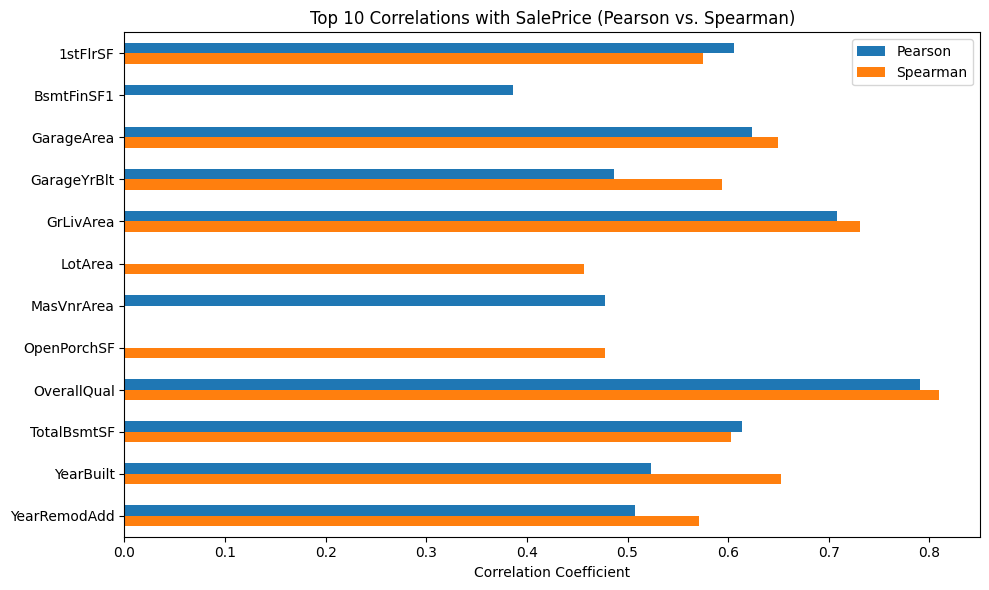

,Pearson,Spearman
1stFlrSF,0.605852,0.575408
BsmtFinSF1,0.386420,NaN
GarageArea,0.623431,0.649379
GarageYrBlt,0.486362,0.593788
GrLivArea,0.708624,0.731310
LotArea,NaN,0.456461
MasVnrArea,0.477493,NaN
OpenPorchSF,NaN,0.477561
OverallQual,0.790982,0.809829
TotalBsmtSF,0.613581,0.602725


In [ ]:
# Import the necessary libraries
import matplotlib.pyplot as plt
%matplotlib inline

# Compute Pearson and Spearman correlations with SalePrice
pearson_corr = df.corr(method='pearson', numeric_only=True)['SalePrice'].sort_values(ascending=False)[1:11]
spearman_corr = df.corr(method='spearman', numeric_only=True)['SalePrice'].sort_values(ascending=False)[1:11]

# Combine into DataFrame
corr_compare = pd.DataFrame({
    'Pearson': pearson_corr,
    'Spearman': spearman_corr
})

# Plot correlations
corr_compare.plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 Correlations with SalePrice (Pearson vs. Spearman)')
plt.xlabel('Correlation Coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

corr_compare


The results show promising correlations between SalePrice and several features, indicating potential predictors for house prices. Consider the different levels of correlation, we would put focus on the 5 top correlation variables from both, Spearman and Pearson

In [ ]:
# Get top 5 features (excluding SalePrice itself) for Pearson and Spearman
top5_pearson = df.corr(method='pearson', numeric_only=True)['SalePrice'].sort_values(ascending=False)[1:6]
top5_spearman = df.corr(method='spearman', numeric_only=True)['SalePrice'].sort_values(ascending=False)[1:6]

# Combine into a DataFrame for comparison
top5_compare = pd.DataFrame({
    'Top 5 Pearson': top5_pearson.index,
    'Pearson Corr': top5_pearson.values,
    'Top 5 Spearman': top5_spearman.index,
    'Spearman Corr': top5_spearman.values
})

top5_compare

,Top 5 Pearson,Pearson Corr,Top 5 Spearman,Spearman Corr
0,OverallQual,0.790982,OverallQual,0.809829
1,GrLivArea,0.708624,GrLivArea,0.731310
2,GarageArea,0.623431,YearBuilt,0.652682
3,TotalBsmtSF,0.613581,GarageArea,0.649379
4,1stFlrSF,0.605852,TotalBsmtSF,0.602725


## Correlation Analysis Categorial Values

It is also important to understand the potential influence of categorical variables on `SalePrice`.

Since these features are not numerical by nature, we cannot apply Pearson or Spearman correlation directly. Instead, we will explore their relationship with the target variable using descriptive statistics and visual analysis.

For this, we will use box plots to compare the distribution of `SalePrice` across the different categories. This approach allows us to visually assess whether certain groups are associated with higher or lower sale prices.


<Figure size 800x500 with 0 Axes>

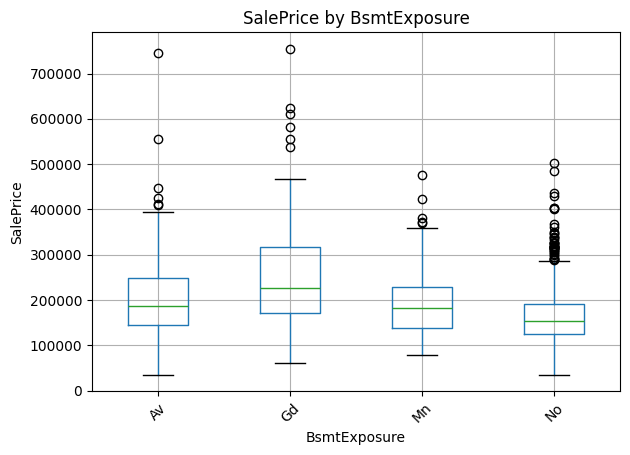

<Figure size 800x500 with 0 Axes>

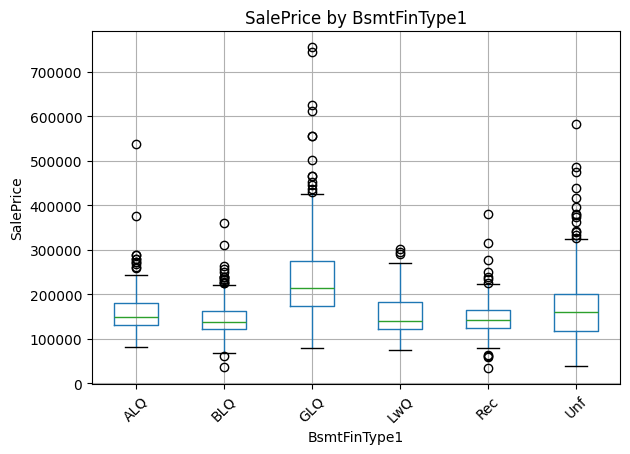

<Figure size 800x500 with 0 Axes>

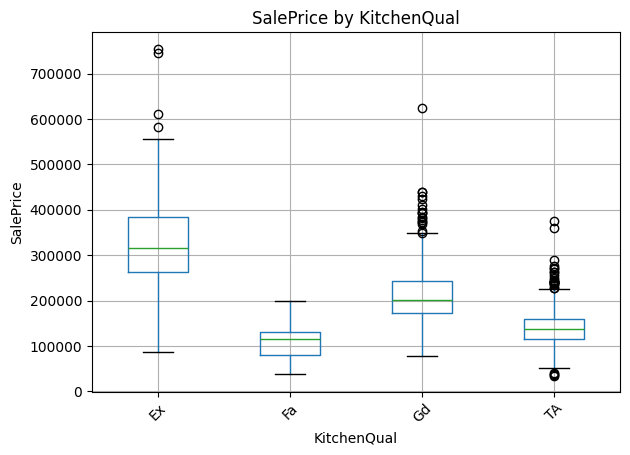

<Figure size 800x500 with 0 Axes>

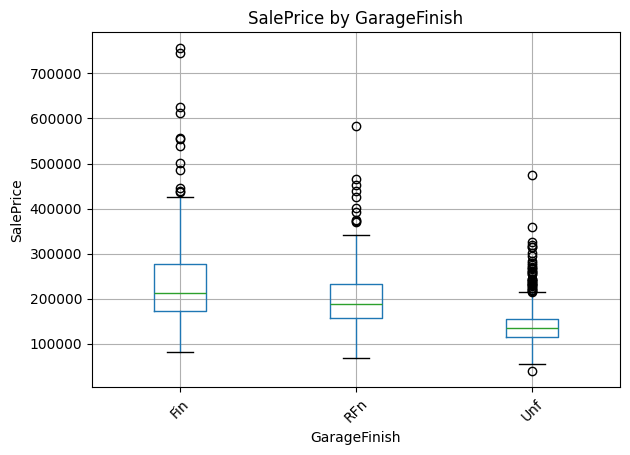

In [ ]:
# Categorical columns to plot
cat_cols = ['BsmtExposure', 'BsmtFinType1', 'KitchenQual', 'GarageFinish']

# Create box plots for each categorical variable vs. SalePrice
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    df.boxplot(column='SalePrice', by=col)
    plt.title(f'SalePrice by {col}')
    plt.suptitle('')
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The box plots above help illustrate how different levels of categorical features relate to `SalePrice`.

- Homes with better basement exposure (`Gd`, `Av`) tend to sell for more, while those with no exposure (`No`) show lower prices.
- Finished basement types like `GLQ` and `ALQ` are associated with higher prices compared to unfinished or rec room types, with a clear upward trend as finish quality improves.
- Kitchen quality shows a strong link to price: `Ex` kitchens top the scale, followed by `Gd`, `TA`, and `Fa`.
- Garage finish matters as well—`Fin` garages correspond to higher sale prices than `RFn` or `Unf`.

Considerint that the  categorical features in the dataset reflect an inherent order, for example, higher quality kitchens or better basement finishes are clearly linked to higher sale prices. 

However, these features are currently stored as text labels, which machine learning models cannot interpret numerically. To ensure the model captures the increasing value associated with better quality, we need to convert these categories into ordered numerical values. Therefore it will be necessary to perform  **ordinal encoding**.


The following mappings reflect logical progressions in quality:

- `KitchenQual`: Fa < TA < Gd < Ex  
- `GarageFinish`: Unf < RFn < Fin  
- `BsmtExposure`: No < Mn < Av < Gd  
- `BsmtFinType1`: Unf < Rec < BLQ < ALQ < GLQ  

By encoding these variables ordinally, we ensure the model interprets higher values as higher quality, improving its ability to learn from these relationships.

### Ordinal Encoding of Categorical Values

Here we apply an orginal encoding of the categorical values using the mapping specified in the section above. The new categorical values and their ouput will be stored in a new CSV file called house_prices_records_encoded.csv


In [ ]:
import os

# Apply  mappings to replace categorical values with numerical encodings
kitchen_qual_map = {'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4}
garage_finish_map = {'Unf': 0, 'RFn': 1, 'Fin': 2}
bsmt_exposure_map = {'No': 0, 'Mn': 1, 'Av': 2, 'Gd': 3}
bsmt_fin_type1_map = {'Unf': 0, 'Rec': 1, 'BLQ': 2, 'ALQ': 3, 'GLQ': 4}

# Reload dataset
df = pd.read_csv(file_path)

# Apply mappings
df['KitchenQual_Enc'] = df['KitchenQual'].map(kitchen_qual_map)
df['GarageFinish_Enc'] = df['GarageFinish'].map(garage_finish_map)
df['BsmtExposure_Enc'] = df['BsmtExposure'].map(bsmt_exposure_map)
df['BsmtFinType1_Enc'] = df['BsmtFinType1'].map(bsmt_fin_type1_map)

# Define save path
output_path = 'outputs/datasets/collection'
os.makedirs(output_path, exist_ok=True)
save_file = os.path.join(output_path, 'house_prices_records_encoded.csv')

# Save to CSV
df.to_csv(save_file, index=False)

save_file


'outputs/datasets/collection\\house_prices_records_encoded.csv'

### Spearman Correlation of Categorical Values



In [20]:
# Select encoded columns + SalePrice
encoded_cols = [
    'KitchenQual_Enc',
    'GarageFinish_Enc',
    'BsmtExposure_Enc',
    'BsmtFinType1_Enc',
    'SalePrice'
]

# Compute Spearman correlation
spearman_corr_encoded = df[encoded_cols].corr(method='spearman')['SalePrice'].drop('SalePrice').sort_values(ascending=False)

# Display result
print(spearman_corr_encoded)


KitchenQual_Enc     0.672849
GarageFinish_Enc    0.595509
BsmtFinType1_Enc    0.342400
BsmtExposure_Enc    0.304819
Name: SalePrice, dtype: float64


After applying ordinal encoding to selected categorical features, we calculated Spearman correlation with `SalePrice` to evaluate their predictive power. Spearman was chosen because it is more appropriate for ordinal data.

Here are the results:

- **KitchenQual_Enc**: 0.67 — strong correlation, indicating kitchen quality is a key driver of price.
- **GarageFinish_Enc**: 0.60 — also strong, confirming finished garages add value.
- **BsmtFinType1_Enc**: 0.34 — moderate, with finished basements showing higher prices.
- **BsmtExposure_Enc**: 0.30 — moderate, suggesting better basement light exposure has a price impact.

These results reinforce what was seen in the box plots and show that ordinal categorical variables hold substantial predictive value.


---

NOTE

* You may add as many sections as you want, as long as they support your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* If you do not need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.